<a href="https://colab.research.google.com/github/srishanthdevoju/Celebal_Internship/blob/main/week6_srishanthdevoju.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.20.0
GPU available: True


In [ ]:
# Load MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize to [0, 1] and reshape to (samples, 28, 28, 1)
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test  = np.expand_dims(x_test, axis=-1)

print(f"Training set : {x_train.shape}")
print(f"Test set     : {x_test.shape}")
print(f"Pixel range  : [{x_train.min():.1f}, {x_train.max():.1f}]")

Training set : (60000, 28, 28, 1)
Test set     : (10000, 28, 28, 1)
Pixel range  : [0.0, 1.0]


In [ ]:
NOISE_FACTOR = 0.5

x_train_noisy = x_train + NOISE_FACTOR * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy  = x_test  + NOISE_FACTOR * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy  = np.clip(x_test_noisy, 0.0, 1.0)

print(f"Noisy pixel range: [{x_train_noisy.min():.2f}, {x_train_noisy.max():.2f}]")

Noisy pixel range: [0.00, 1.00]


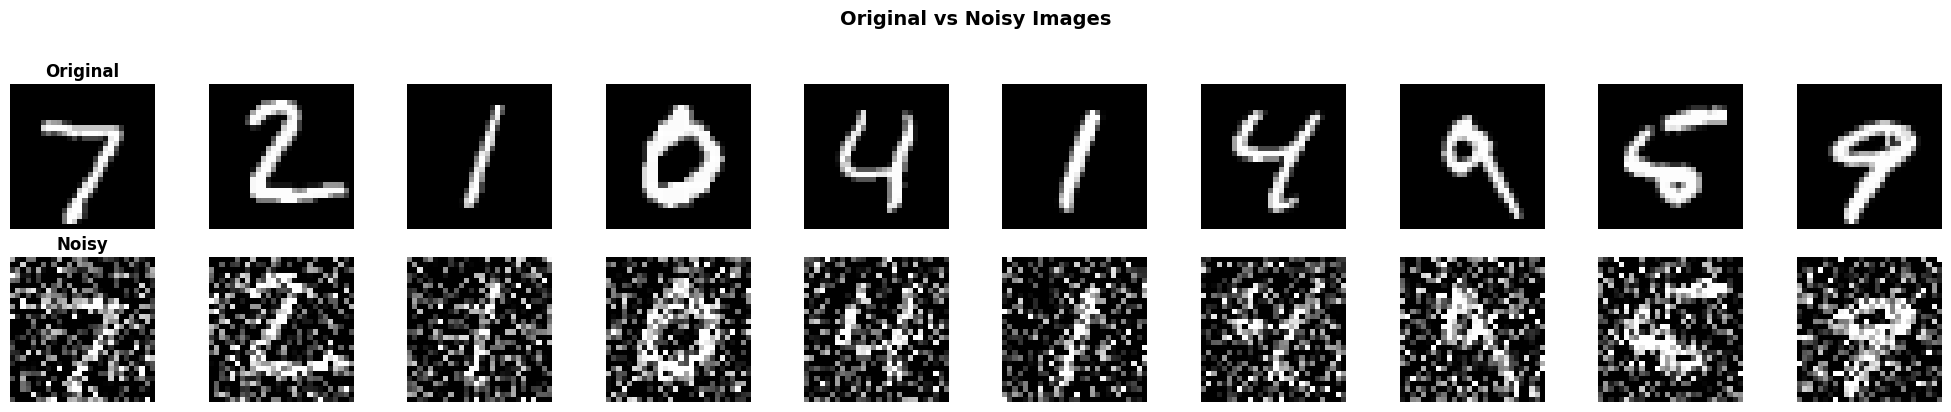

In [ ]:
n_display = 10
fig, axes = plt.subplots(2, n_display, figsize=(20, 4))

for i in range(n_display):
    # Original
    axes[0, i].imshow(x_test[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=12, fontweight='bold')

    # Noisy
    axes[1, i].imshow(x_test_noisy[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Noisy', fontsize=12, fontweight='bold')

plt.suptitle('Original vs Noisy Images', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('original_vs_noisy_images.png')
plt.show()
plt.close(fig)

In [ ]:
def build_denoising_autoencoder():
    """Build a convolutional denoising autoencoder."""

    input_img = layers.Input(shape=(28, 28, 1), name='input')

    # ---- ENCODER ----
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='enc_conv1')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same', name='enc_pool1')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='enc_conv2')(x)
    x = layers.MaxPooling2D((2, 2), padding='same', name='enc_pool2')(x)
    encoded = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='bottleneck')(x)

    # ---- DECODER ----
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='dec_conv1')(encoded)
    x = layers.UpSampling2D((2, 2), name='dec_upsample1')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='dec_conv2')(x)
    x = layers.UpSampling2D((2, 2), name='dec_upsample2')(x)
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='output')(x)

    autoencoder = Model(input_img, decoded, name='Denoising_Autoencoder')
    return autoencoder


autoencoder = build_denoising_autoencoder()
autoencoder.summary()

Model: "Denoising_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Conv2D)             │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_upsample1 (UpSampling2D)    │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2D)              │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_upsample2 (UpSampling2D)    │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Conv2D)                 │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,625 (1.20 MB)

 Trainable params: 314,625 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

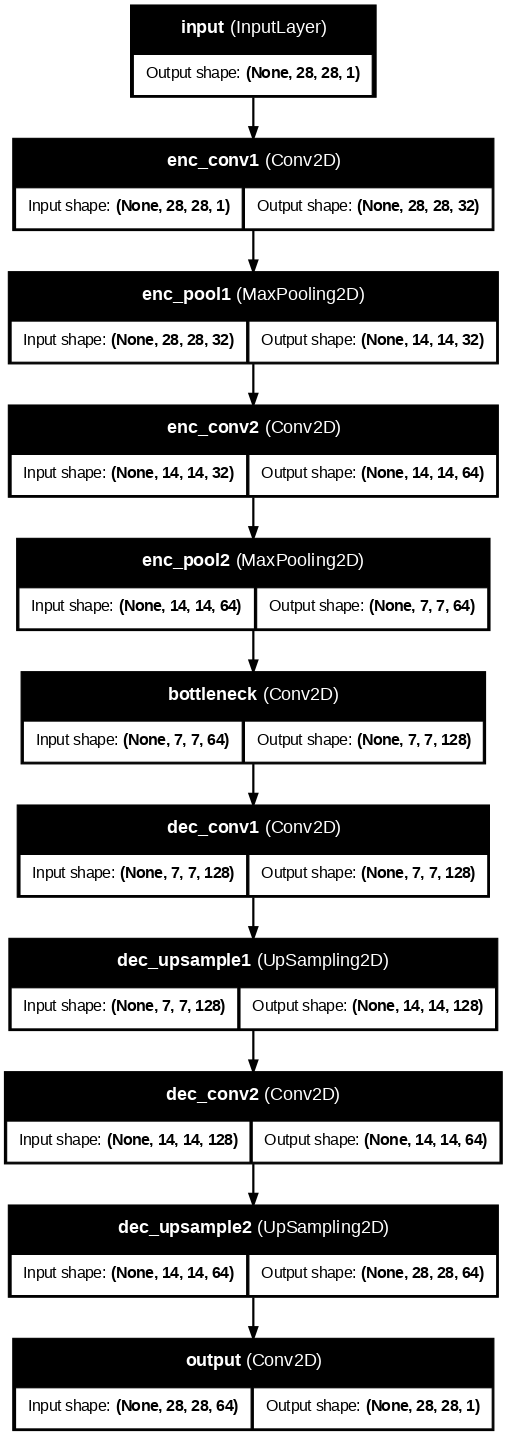

In [ ]:
# Visualize model architecture
tf.keras.utils.plot_model(
    autoencoder,
    show_shapes=True,
    show_layer_names=True,
    dpi=80
)

In [ ]:
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['mse']
)

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
    )
]

print("Training the Denoising Autoencoder...")
print(f"Input : noisy images  →  Target : clean images")
print(f"{'='*50}")
EPOCHS = 50
BATCH_SIZE = 128

history = autoencoder.fit(
    x_train_noisy, x_train,        # noisy → clean
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=callbacks,
    verbose=1
)

Training the Denoising Autoencoder...
Input : noisy images  →  Target : clean images
Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - loss: 0.1423 - mse: 0.0258 - val_loss: 0.1049 - val_mse: 0.0139 - learning_rate: 0.0010
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.1030 - mse: 0.0132 - val_loss: 0.0993 - val_mse: 0.0122 - learning_rate: 0.0010
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0991 - mse: 0.0120 - val_loss: 0.0969 - val_mse: 0.0113 - learning_rate: 0.0010
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0969 - mse: 0.0113 - val_loss: 0.0954 - val_mse: 0.0109 - learning_rate: 0.0010
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0955 - mse: 0.0108 - val_loss: 0.0944 - val_mse: 0.0106 - learning_rate: 0.0010
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0945 - mse: 0.0105 - val_loss: 0.0938 - val_mse: 0.0104 - learning_rate: 0.0010
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - l

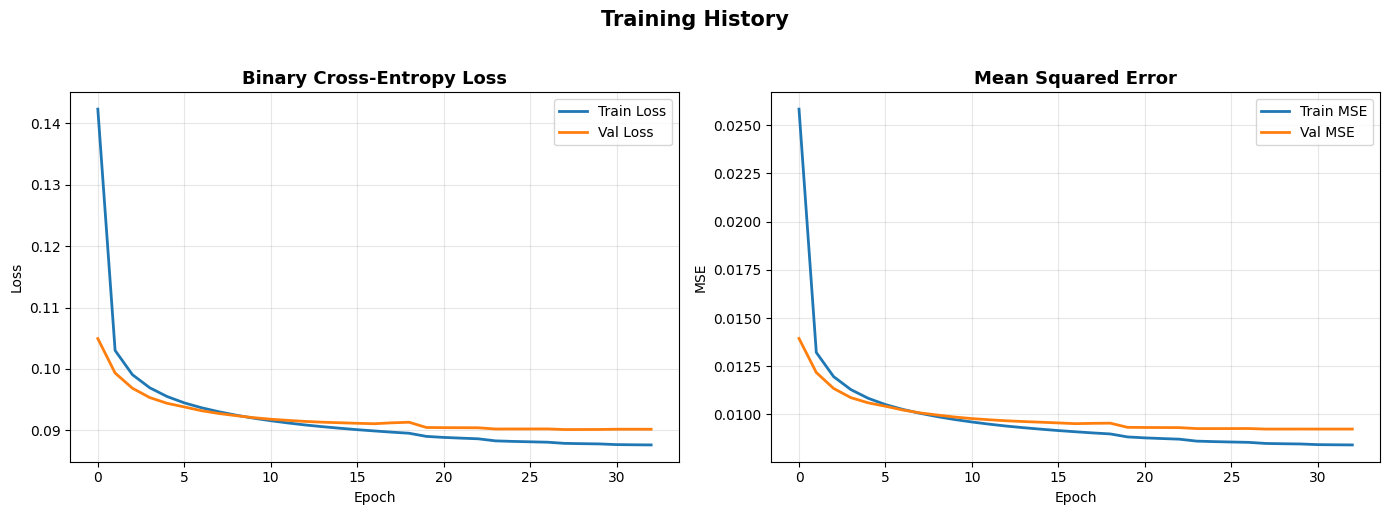


Final Validation Loss : 0.09019
Final Validation MSE  : 0.00924


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('Binary Cross-Entropy Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MSE
axes[1].plot(history.history['mse'], label='Train MSE', linewidth=2)
axes[1].plot(history.history['val_mse'], label='Val MSE', linewidth=2)
axes[1].set_title('Mean Squared Error', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_history.png')
plt.show()
plt.close(fig)

# Final metrics
final_val_loss = history.history['val_loss'][-1]
final_val_mse  = history.history['val_mse'][-1]
print(f"\nFinal Validation Loss : {final_val_loss:.5f}")
print(f"Final Validation MSE  : {final_val_mse:.5f}")

Denoised output shape : (10000, 28, 28, 1)
Pixel range           : [0.000, 0.999]


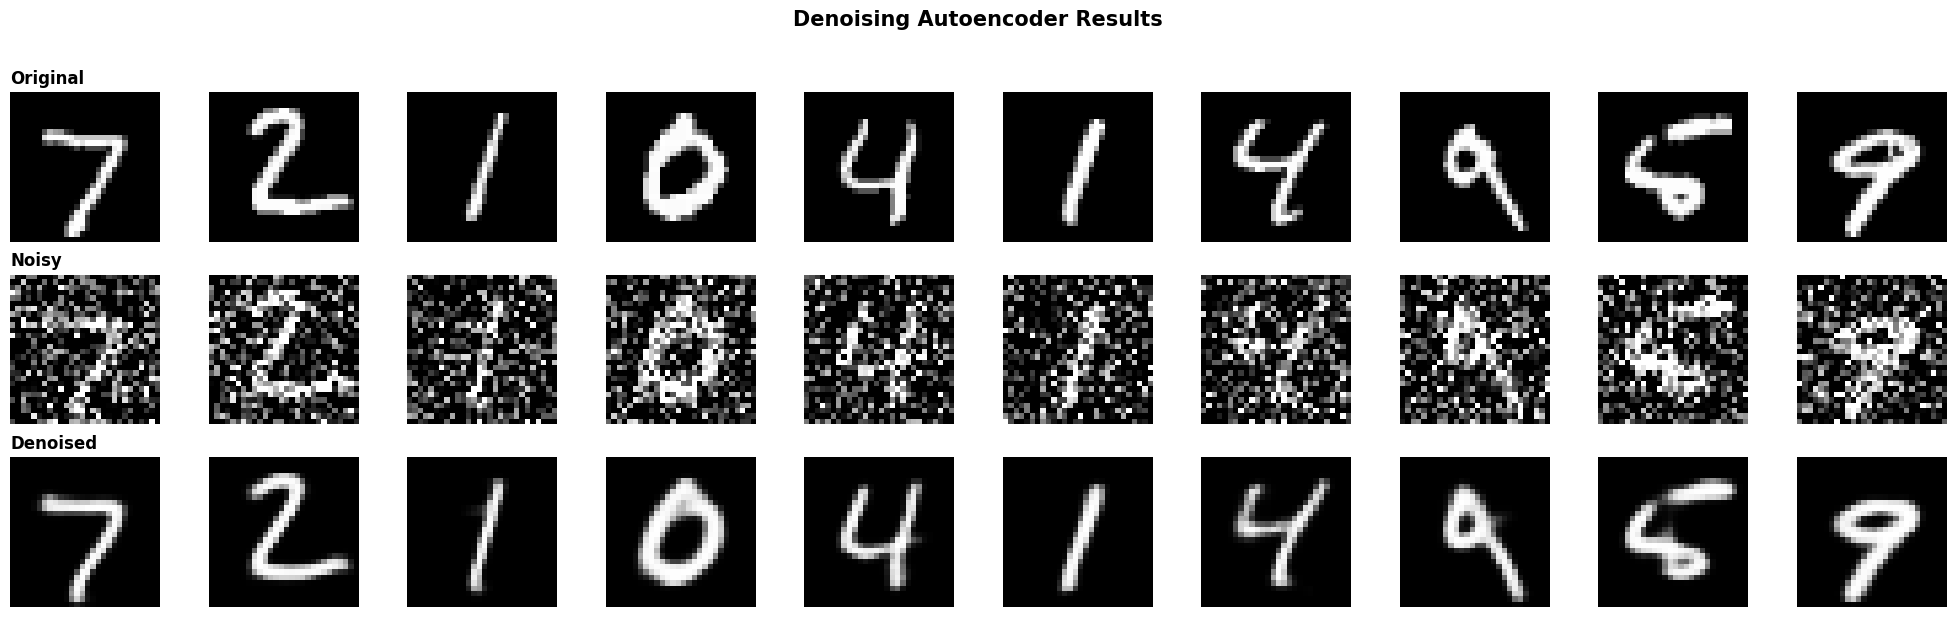

In [ ]:
# Generate denoised images
denoised_images = autoencoder.predict(x_test_noisy, verbose=0)

print(f"Denoised output shape : {denoised_images.shape}")
print(f"Pixel range           : [{denoised_images.min():.3f}, {denoised_images.max():.3f}]")
n_display = 10
fig, axes = plt.subplots(3, n_display, figsize=(20, 6))

row_labels = ['Original', 'Noisy', 'Denoised']

for i in range(n_display):
    # Original
    axes[0, i].imshow(x_test[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')

    # Noisy
    axes[1, i].imshow(x_test_noisy[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

    # Denoised
    axes[2, i].imshow(denoised_images[i].squeeze(), cmap='gray')
    axes[2, i].axis('off')

# Row labels
for ax, label in zip(axes[:, 0], row_labels):
    ax.set_title(label, fontsize=12, fontweight='bold', loc='left')

plt.suptitle('Denoising Autoencoder Results', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('denoising_autoencoder_results.png')
plt.show()
plt.close(fig)

In [ ]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def compute_metrics(original, compared, label):
    """Compute average PSNR and SSIM over the test set."""
    psnr_vals = []
    ssim_vals = []
    for i in range(len(original)):
        orig = original[i].squeeze()
        comp = compared[i].squeeze()
        psnr_vals.append(psnr(orig, comp, data_range=1.0))
        ssim_vals.append(ssim(orig, comp, data_range=1.0))
    avg_psnr = np.mean(psnr_vals)
    avg_ssim = np.mean(ssim_vals)
    print(f"{label:>12s}  →  PSNR: {avg_psnr:.2f} dB  |  SSIM: {avg_ssim:.4f}")
    return avg_psnr, avg_ssim

print("Image Quality Metrics (vs. Original Clean Images)")
print("=" * 55)
noisy_psnr, noisy_ssim       = compute_metrics(x_test, x_test_noisy, 'Noisy')
denoised_psnr, denoised_ssim = compute_metrics(x_test, denoised_images, 'Denoised')

print(f"\n{'─'*55}")
print(f"PSNR Improvement : +{denoised_psnr - noisy_psnr:.2f} dB")
print(f"SSIM Improvement : +{denoised_ssim - noisy_ssim:.4f}")

Image Quality Metrics (vs. Original Clean Images)
       Noisy  →  PSNR: 9.39 dB  |  SSIM: 0.3752
    Denoised  →  PSNR: 20.73 dB  |  SSIM: 0.8884

───────────────────────────────────────────────────────
PSNR Improvement : +11.34 dB
SSIM Improvement : +0.5132


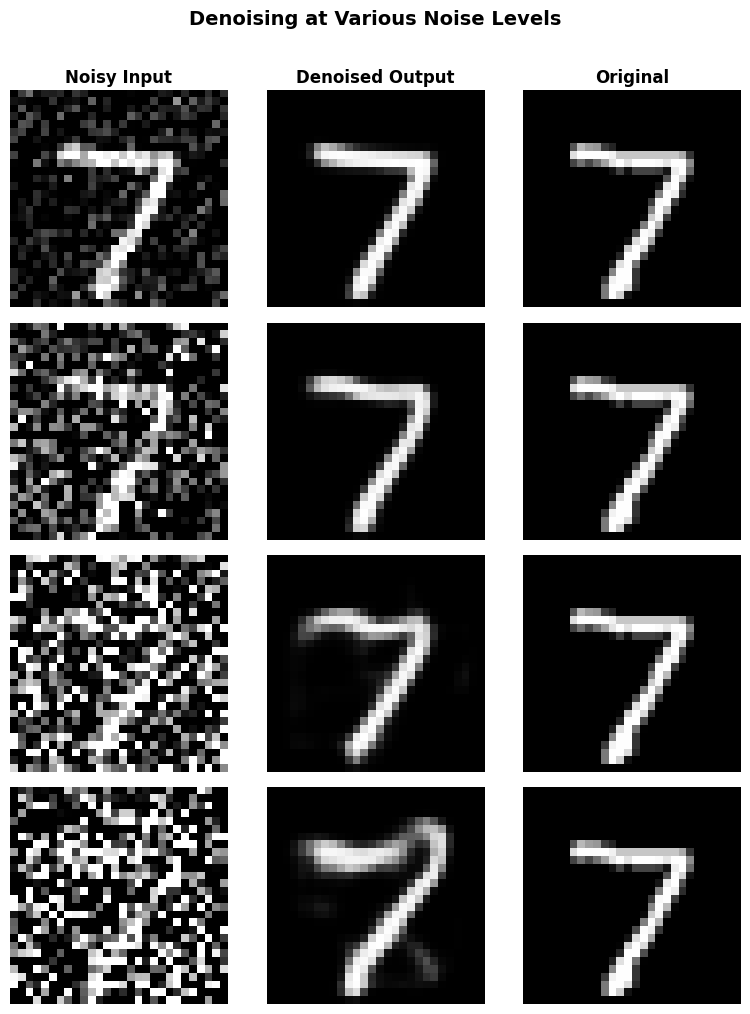

In [ ]:
noise_levels = [0.2, 0.5, 0.8, 1.0]
sample_idx = 0

fig, axes = plt.subplots(len(noise_levels), 3, figsize=(8, 10))
col_titles = ['Noisy Input', 'Denoised Output', 'Original']

for row, nf in enumerate(noise_levels):
    # Create noisy version
    noisy = x_test[sample_idx] + nf * np.random.normal(0, 1, x_test[sample_idx].shape)
    noisy = np.clip(noisy, 0.0, 1.0)

    # Denoise
    denoised = autoencoder.predict(noisy[np.newaxis, ...], verbose=0)[0]

    axes[row, 0].imshow(noisy.squeeze(), cmap='gray')
    axes[row, 0].set_ylabel(f'σ = {nf}', fontsize=11, fontweight='bold', rotation=0, labelpad=40)
    axes[row, 1].imshow(denoised.squeeze(), cmap='gray')
    axes[row, 2].imshow(x_test[sample_idx].squeeze(), cmap='gray')

    for col in range(3):
        axes[row, col].axis('off')

# Column titles
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Denoising at Various Noise Levels', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('denoising_at_various_noise_levels.png')
plt.show()
plt.close(fig)

Latent space shape: (1, 7, 7, 128)


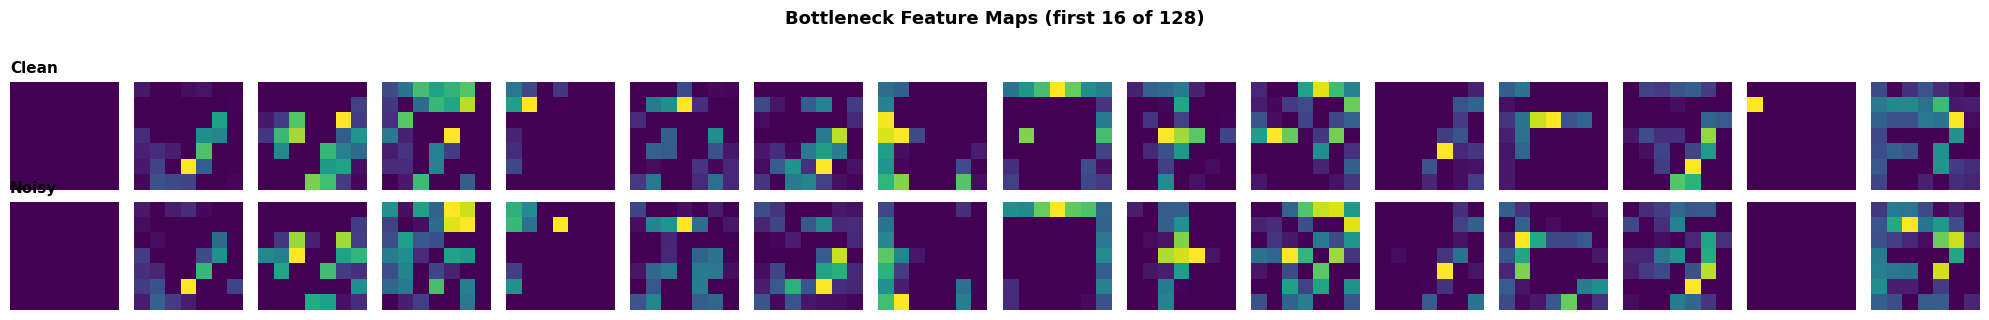

In [ ]:
# Extract encoder part
encoder = Model(autoencoder.input, autoencoder.get_layer('bottleneck').output, name='Encoder')

sample = x_test[0:1]
sample_noisy = x_test_noisy[0:1]

latent_clean = encoder.predict(sample, verbose=0)
latent_noisy = encoder.predict(sample_noisy, verbose=0)

print(f"Latent space shape: {latent_clean.shape}")
n_maps = 16
fig, axes = plt.subplots(2, n_maps, figsize=(20, 3))

for i in range(n_maps):
    axes[0, i].imshow(latent_clean[0, :, :, i], cmap='viridis')
    axes[0, i].axis('off')
    axes[1, i].imshow(latent_noisy[0, :, :, i], cmap='viridis')
    axes[1, i].axis('off')

axes[0, 0].set_title('Clean', fontsize=11, fontweight='bold', loc='left')
axes[1, 0].set_title('Noisy', fontsize=11, fontweight='bold', loc='left')
plt.suptitle('Bottleneck Feature Maps (first 16 of 128)', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('bottleneck_feature_maps.png')
plt.show()
plt.close(fig)

In [ ]:
autoencoder.save('denoising_autoencoder_mnist.keras')
print("Model saved as 'denoising_autoencoder_mnist.keras'")

Model saved as 'denoising_autoencoder_mnist.keras'


---

## Summary

| Aspect | Detail |
|---|---|
| **Model** | Convolutional Denoising Autoencoder |
| **Dataset** | MNIST (60K train / 10K test) |
| **Noise** | Gaussian, σ = 0.5 |
| **Loss** | Binary Cross-Entropy |
| **Optimizer** | Adam (lr=1e-3) |
| **Encoder** | Conv(32) → Pool → Conv(64) → Pool → Conv(128) |
| **Decoder** | Conv(128) → UpSample → Conv(64) → UpSample → Conv(1, sigmoid) |
| **Metrics** | PSNR, SSIM (via scikit-image) |

###Conclusion & Key Findings
In this project, we built and evaluated a Convolutional Denoising Autoencoder to clean heavily corrupted digits from the MNIST dataset ($\sigma = 0.5$). By forcing the network to compress inputs into a dense bottleneck layer ($7 \times 7 \times 128$) and perfectly mirror them back out, the model successfully learned to separate meaningful structural topology from random noise.